In [1]:
from vmc_ising import (
    output_dir,
    get_config,
    get_lattice,
    default_config,
    get_network,
    get_system,
)
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

def smooth(column, window, groupby=None):
    def wrapper(df):
        if groupby is not None:
            return (df.groupby(groupby)
                    .apply(lambda group_df: group_df.assign(
                        **{column: lambda df: df[column].rolling(window, center=True).mean()}
                    )).dropna(subset=[column])
                    .reset_index(level=0, drop=True)
                    )
        else:
            return df.assign(
                **{column: lambda df: df[column].rolling(window, center=True).mean()}
            ).dropna(subset=[column])
    return wrapper


Running dilated_nns_xors.py


In [2]:
df = (
    read_jsonl_to_df(output_dir.glob("56/results.jsonl"))
    .fillna(keep_serializable(default_config))
    # .assign(
    #     n_signs_updated=lambda df: df.groupby("task_id")["signs_updated"].transform(
    #         "cumsum"
    #     )
    # )
)

In [23]:
df.query('task_id == 55').columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps',
       'config_sign_reconstruction.repetitions', 'config_warm_up.sign_noise',
       'config_checkpoint_log_prob_fn_each', 'config_log_prob_fn',
       'config_kernel_size', 'amplitude_overlap', '‖∇E‖₂', 'E_full_delta',
       'ipr', 'step', 'E_variance', 'start_timestamp', 'task_id', 'device',
       'warm_up', 'sign_overlap', 'step_since_warm_up', 'signs_updated',
       'signs_updated_at', 'step_since_signs_updated', 'git_hash',
       'config_checkpoint_log_prob_fn_on_sign_update',
       'config_checkpoint_signs', 

In [27]:
df.query('task_id == 55 and start_timestamp == "2024_03_13_21_21_01"')['step'].max()

179

In [3]:
df.query('task_id == 56 and signs_updated').iloc[0]

config_n_samples                                                                                   10000
config_lr                                                                                          0.001
config_batch_size                                                                                  10000
config_weight_decay                                                                                    0
config_max_iter                                                                                     1000
config_lattice                                                                                 kagome2x4
config_J2                                                                                              1
config_use_symmetries                                                                              False
config_spin_inversion                                                                               None
config_eval_set_max_size                               

In [26]:
-43.0395889923 + 5.574253

-37.4653359923

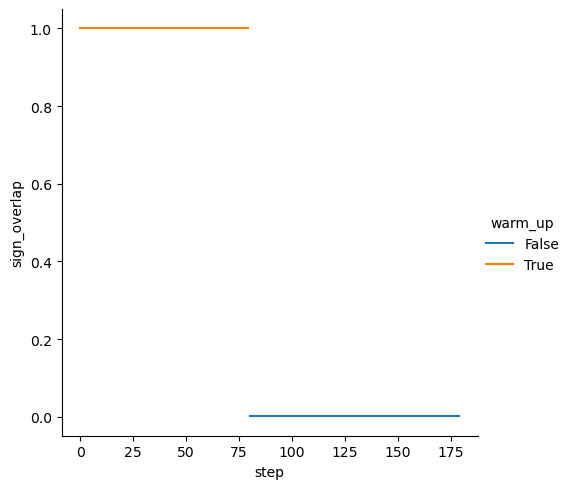

In [20]:
sns.relplot(
    df.query('task_id == 55 and start_timestamp == "2024_03_13_21_21_01"'),
    x="step",
    y="sign_overlap",
    kind='line',
    hue='warm_up'
)

In [9]:
df.query("`config_sign_reconstruction.method` == 'annealing' and config_max_iter > 15000")["task_id"].unique()

array([34, 37, 27, 33, 36, 31, 39, 26, 29, 32, 35, 30])

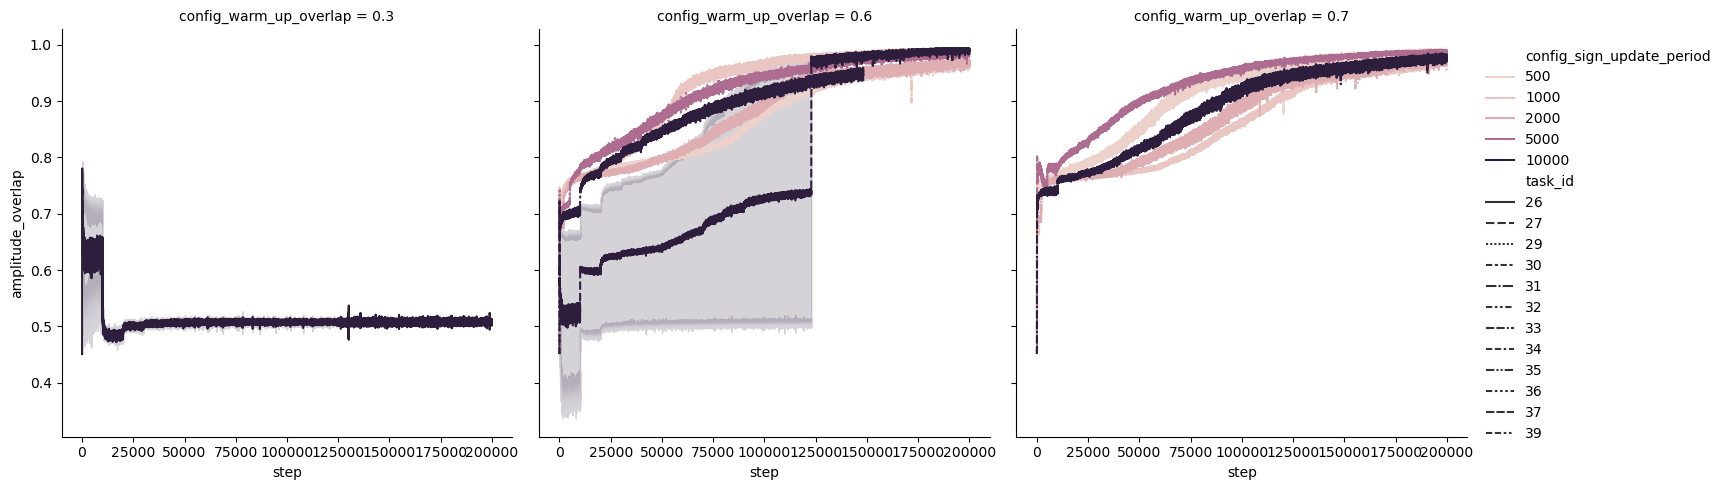

In [11]:
sns.relplot(
    df.query(
        "`config_sign_reconstruction.method` == 'annealing'"
        "and config_max_iter > 15000"
    ),  # .pipe(smooth("amplitude_overlap", 100, groupby="task_id"))
    x="step",
    y="amplitude_overlap",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    # hue="warm_up",
    kind="line",
    col_wrap=3,
    style="task_id",
)  # .set(yscale="log")

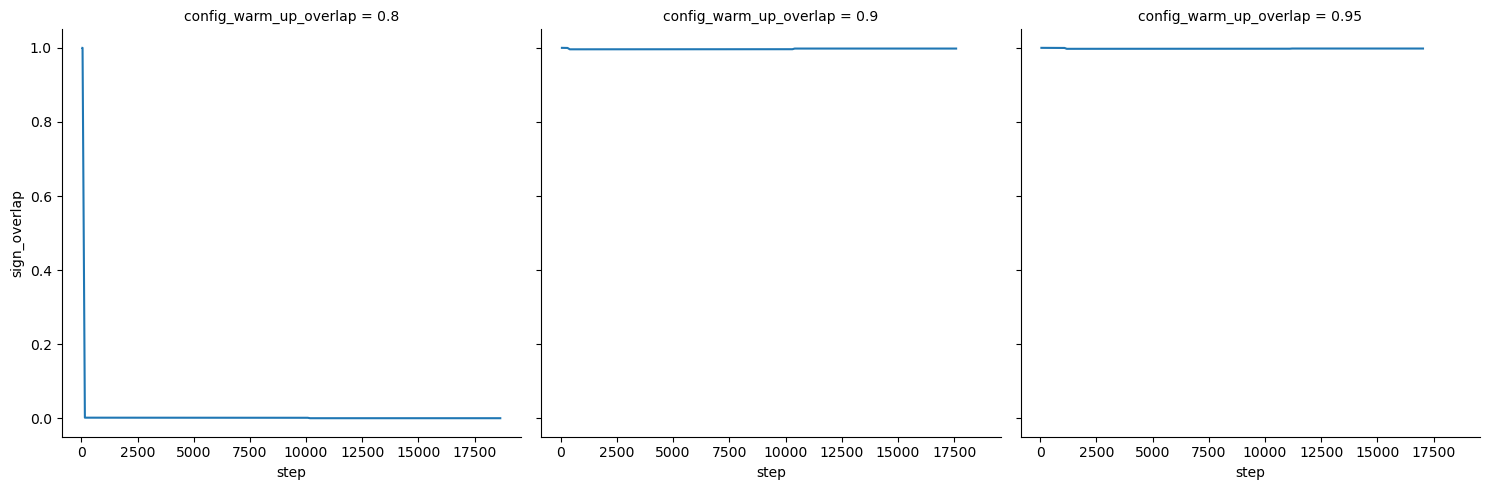

In [6]:
sns.relplot(
    df.query(
        "`config_sign_reconstruction.method` == 'greedy_solve' and task_id >= 52"
    ).pipe(smooth("sign_overlap", 100, groupby="task_id")),
    x="step",
    y="sign_overlap",
    #hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
)  # .set(yscale="log")

In [21]:
df.query('task_id == 25').assign(
        amplitude_overlap=lambda df: df["amplitude_overlap"].rolling(100, center=True).mean()
    ).dropna(subset=["amplitude_overlap"])[['step', 'amplitude_overlap']]

,step,amplitude_overlap
2634785,50,0.632199
2634786,51,0.634743
2634787,52,0.637279
2634788,53,0.639807
2634789,54,0.642329
...,...,...
2649681,14946,0.768610
2649682,14947,0.768607
2649683,14948,0.768585
2649684,14949,0.768582


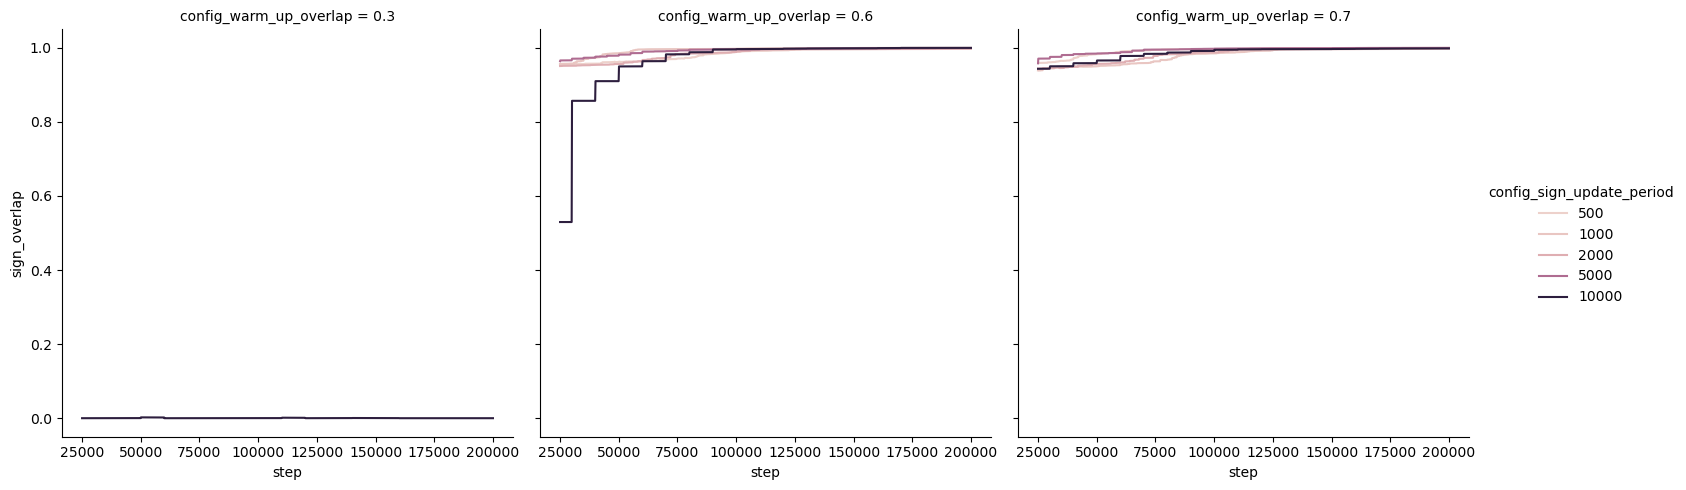

In [8]:
sns.relplot(
    df.query(
        "25 <= task_id <= 37 and task_id != 28 and not git_hash.isna()"
        "and step > 25000"
    ).pipe(smooth("sign_overlap", 100, "task_id")),
    x="step",
    y="sign_overlap",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
)

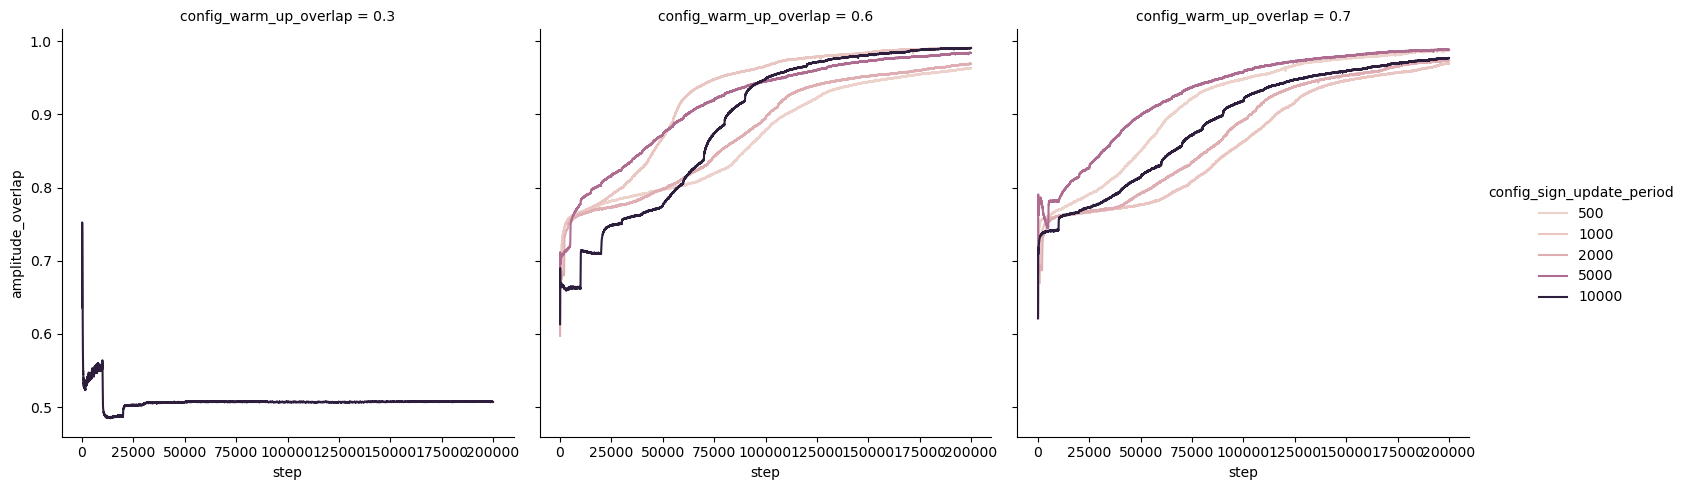

In [9]:
sns.relplot(
    df.query("25 <= task_id <= 37 and task_id != 28 and not git_hash.isna()").pipe(
        smooth("amplitude_overlap", 100, groupby="task_id")
    ),
    x="step",
    y="amplitude_overlap",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
)

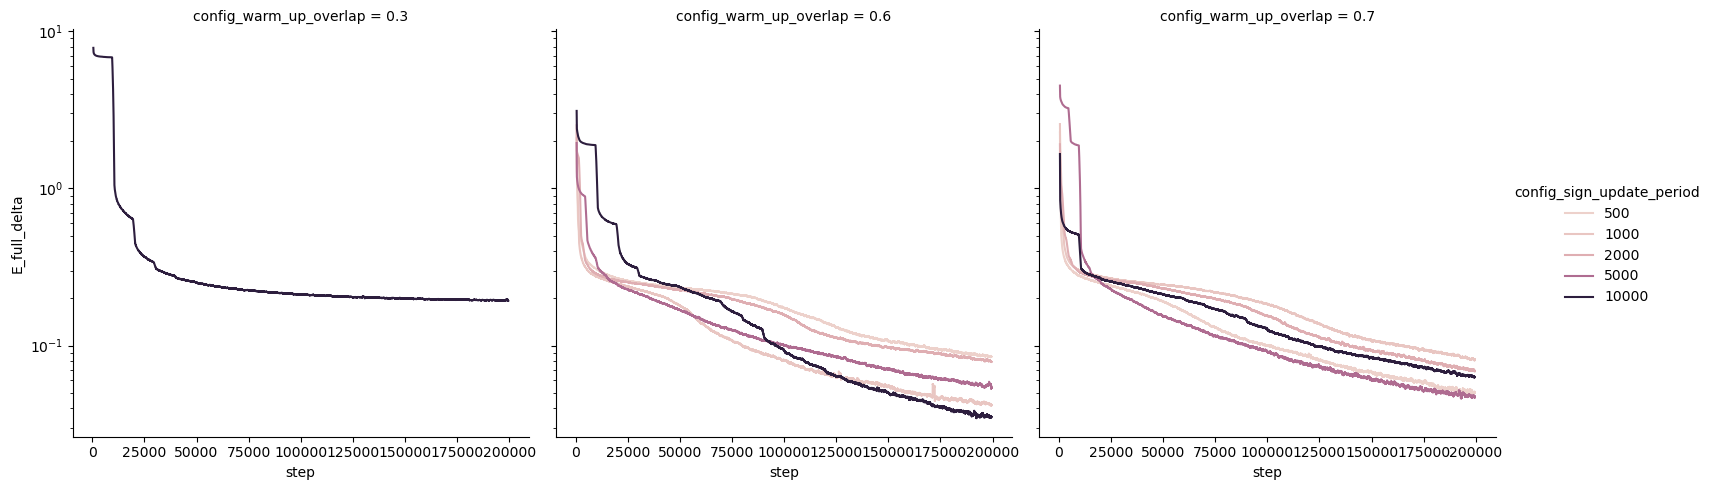

In [55]:
sns.relplot(
    df.query("25 <= task_id <= 37 and task_id != 28 and not git_hash.isna()").pipe(
        smooth("E_full_delta", 1000, groupby="task_id")
    ),
    x="step",
    y="E_full_delta",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
).set(yscale="log")

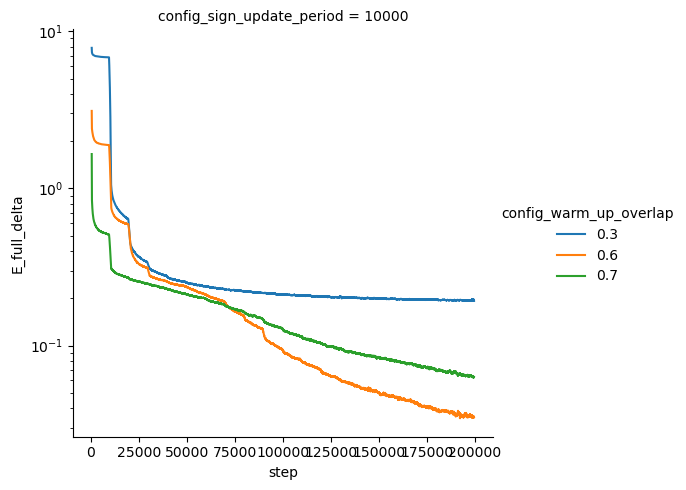

In [54]:
sns.relplot(
    df.query(
        "25 <= task_id <= 37 and task_id != 28 and not git_hash.isna() "
        "and config_sign_update_period == 10000"
    )
    .pipe(column_to(str, "config_warm_up_overlap"))
    .pipe(smooth("E_full_delta", 1000, groupby="task_id")),
    x="step",
    y="E_full_delta",
    col="config_sign_update_period",
    hue="config_warm_up_overlap",
    kind="line",
).set(yscale="log")

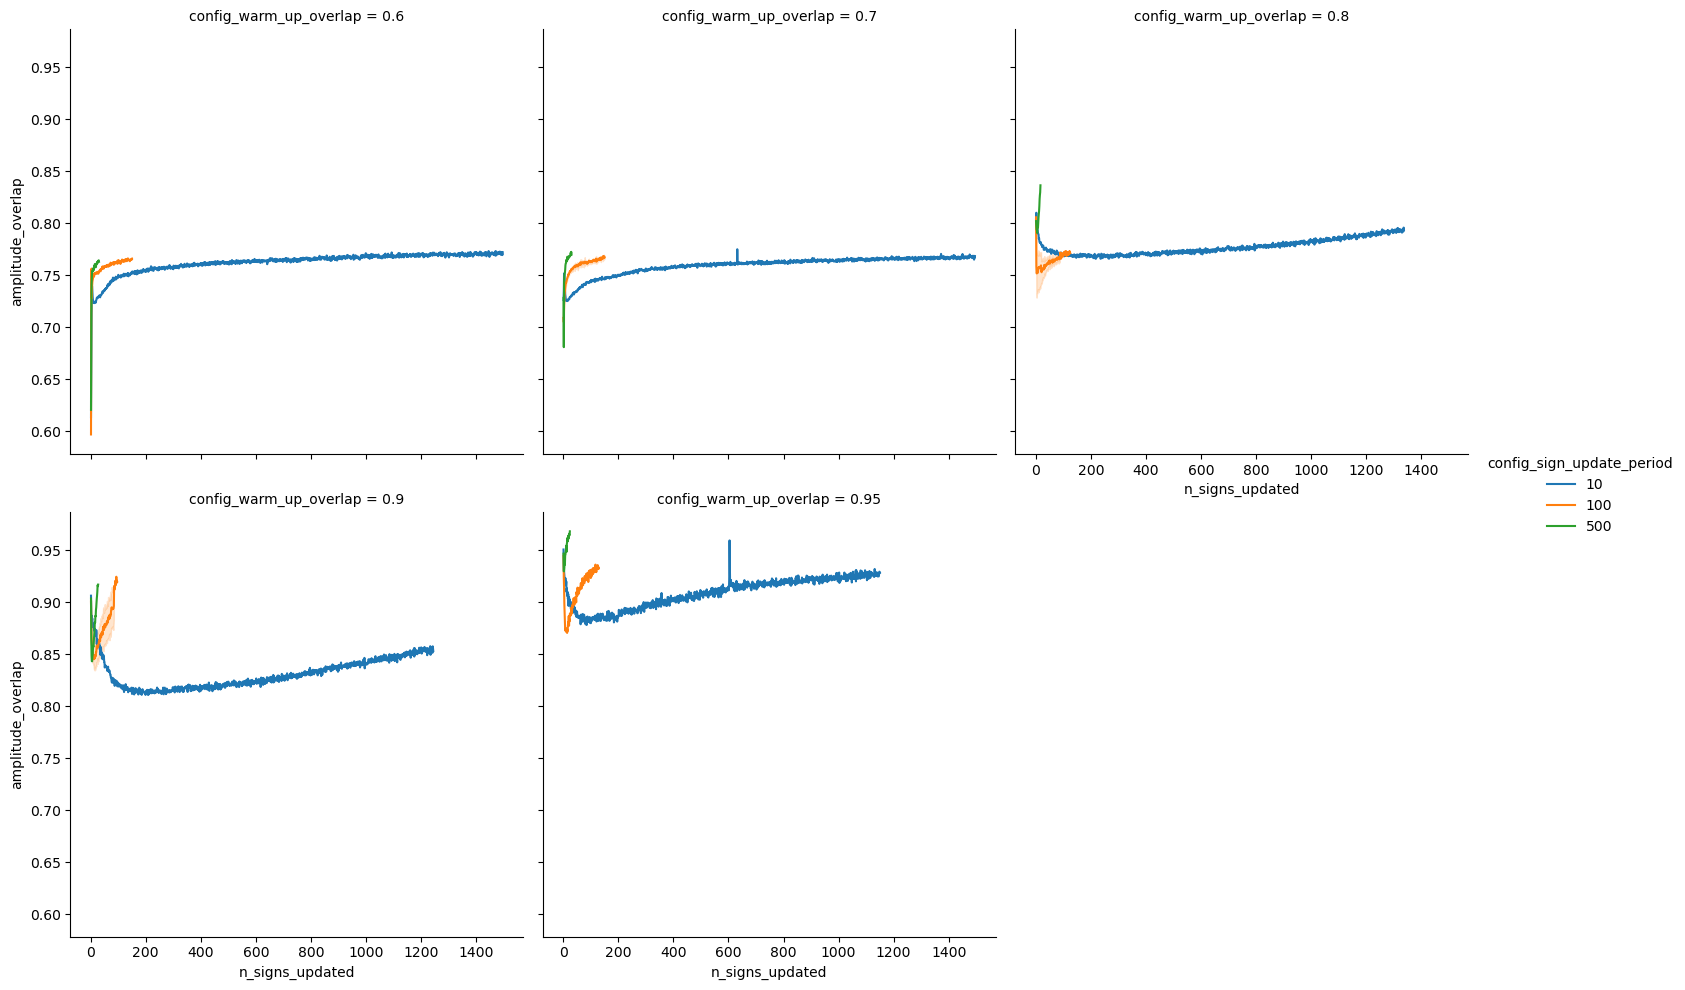

In [28]:
sns.relplot(
    df.query("task_id > 0 and signs_updated").pipe(
        column_to(str, "config_sign_update_period")
    ),
    x="n_signs_updated",
    y="amplitude_overlap",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    kind="line",
    col_wrap=3,
)

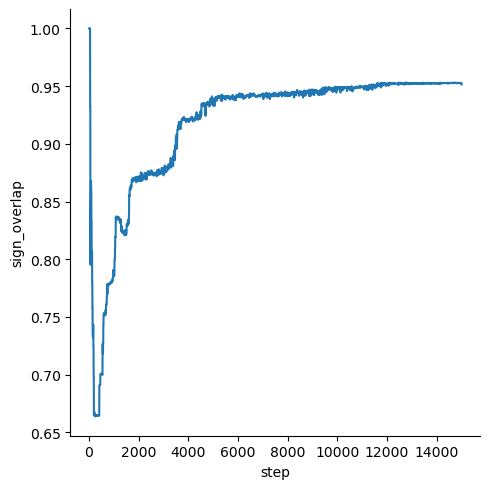

In [9]:
sns.relplot(df.query("task_id == 13"), x="step", y="sign_overlap", kind="line")

In [6]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'overlap'],
      dtype='object')

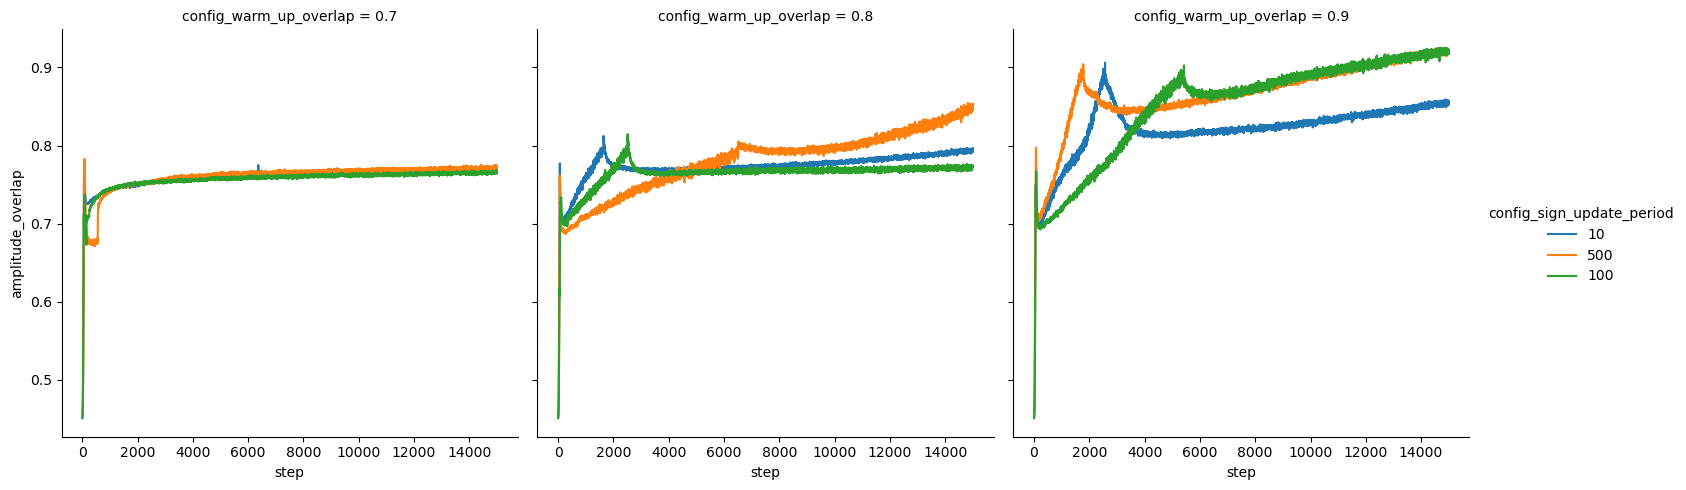

In [15]:
sns.relplot(
    df.query("task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7").pipe(
        column_to(str, "config_sign_update_period")
    ),
    x="step",
    y="amplitude_overlap",
    kind="line",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    col_wrap=3,
)

In [20]:
df.query("task_id == 10").iloc[0]

config_n_samples                                          10000
config_lr                                                 0.001
config_batch_size                                         10000
config_weight_decay                                           0
config_max_iter                                           15000
config_lattice                                        kagome2x3
config_J2                                                     1
config_use_symmetries                                     False
config_spin_inversion                                      None
config_eval_set_max_size                                  50000
config_device                                              auto
config_random_seed                                         None
config_dilations                                           None
config_hidden_channels                             [32, 32, 32]
config_warm_up_overlap                                      0.7
config_sign_update_period               

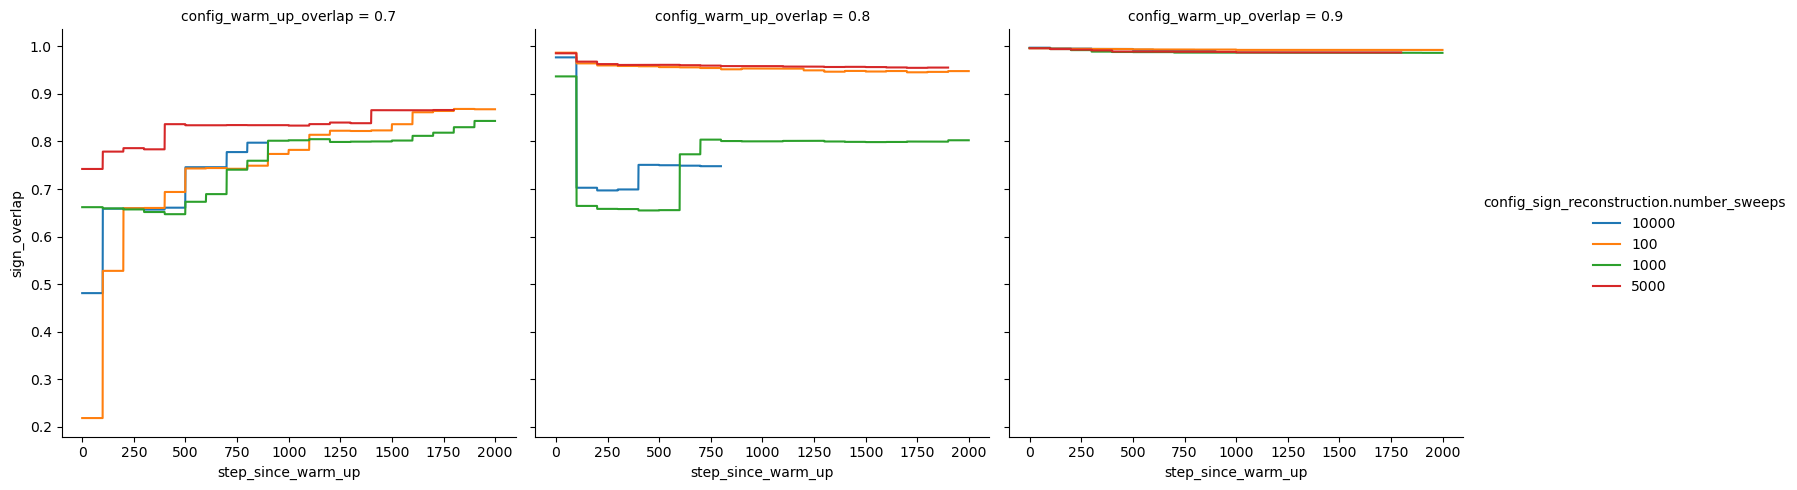

In [12]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and step_since_warm_up < 2000"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="sign_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

In [9]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'config_sign_reconstruction.repetitions', 'overlap'],
      dtype='object')

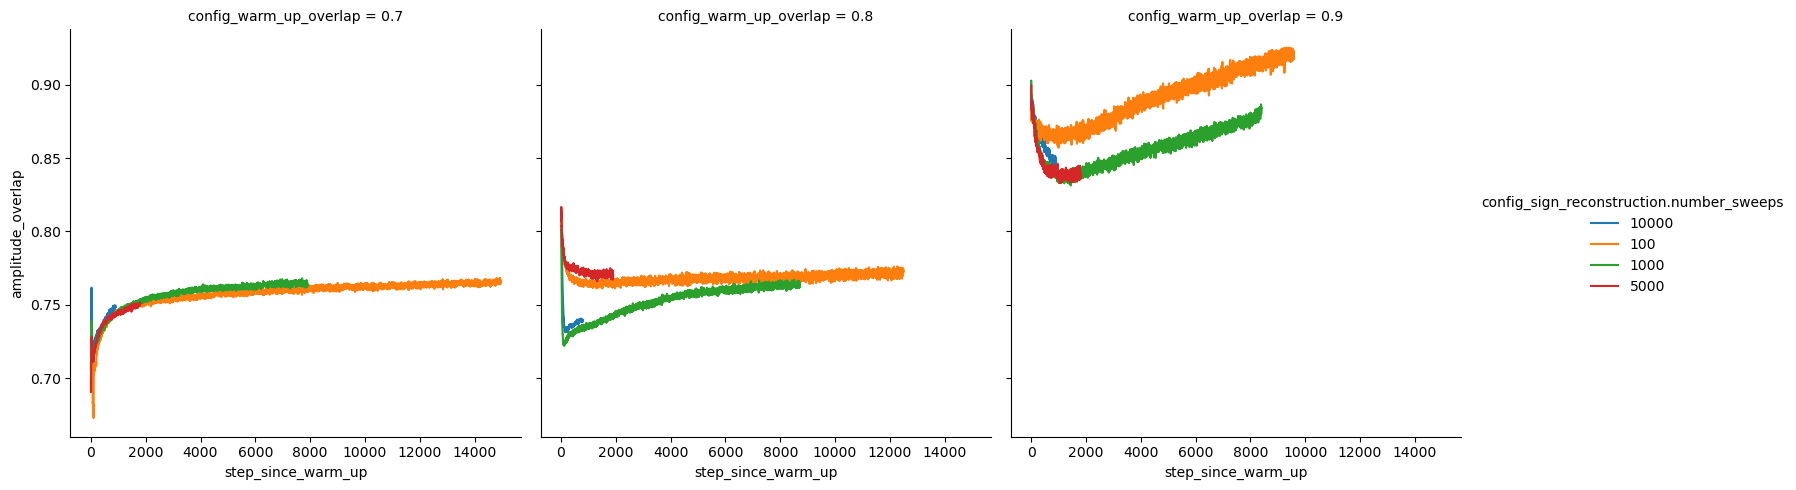

In [10]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

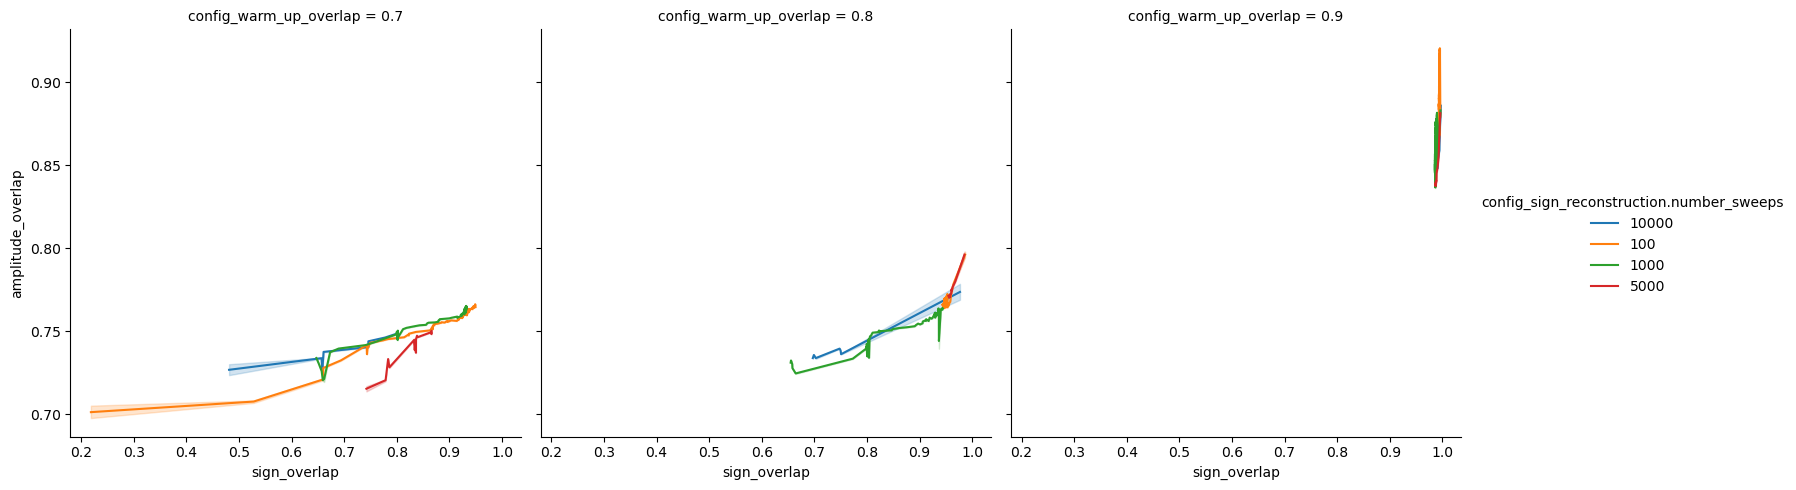

In [13]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and not warm_up"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="sign_overlap",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

In [3]:
task_id = 25
config = get_config(task_id)
log_prob_fn = get_network(config, get_system(config))

2024-03-07 14:48:35.473 | DEBUG    | heisenberg_hamiltonians:__init__:526 - number_spins=18
2024-03-07 14:48:35.474 | DEBUG    | heisenberg_hamiltonians:__init__:528 - Setting hamming_weight to half
2024-03-07 14:48:35.475 | DEBUG    | heisenberg_hamiltonians:__init__:541 - Symmetry group contains 0 elements
2024-03-07 14:48:35.475 | DEBUG    | heisenberg_hamiltonians:__init__:542 - Constructing basis
2024-03-07 14:48:35.495 | DEBUG    | heisenberg_hamiltonians:__init__:550 - Hilbert space dimension is 48620


In [4]:
log_prob_fn.load_state_dict(
    torch.load(
        output_dir / f"{task_id}/log_prob_fn_{1000}.pt",
        map_location=torch.device("cpu"),
    )
)

<All keys matched successfully>

In [6]:
log_prob_fn(torch.tensor([1, 2, 3], dtype=torch.int64))

tensor([[ -7.9140],
        [ -7.2719],
        [-10.9693]], grad_fn=<AddmmBackward0>)

In [ ]:
2